Loading the dataset

In [2]:
import pandas as pd

df = pd.read_csv('/content/ad_10000records.csv')

display(df.head())

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Gender,Country,Timestamp,Clicked on Ad
0,62.26,32.0,69481.85,172.83,Decentralized real-time circuit,Lisafort,Male,Svalbard & Jan Mayen Islands,2016-06-09 21:43:05,0
1,41.73,31.0,61840.26,207.17,Optional full-range projection,West Angelabury,Male,Singapore,2016-01-16 17:56:05,0
2,44.40,30.0,57877.15,172.83,Total 5thgeneration standardization,Reyesfurt,Female,Guadeloupe,2016-06-29 10:50:45,0
3,59.88,28.0,56180.93,207.17,Balanced empowering success,New Michael,Female,Zambia,2016-06-21 14:32:32,0
4,49.21,30.0,54324.73,201.58,Total 5thgeneration standardization,West Richard,Female,Qatar,2016-07-21 10:54:35,1


Print Schema

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Daily Time Spent on Site  10000 non-null  float64
 1   Age                       10000 non-null  float64
 2   Area Income               10000 non-null  float64
 3   Daily Internet Usage      10000 non-null  float64
 4   Ad Topic Line             10000 non-null  object 
 5   City                      10000 non-null  object 
 6   Gender                    10000 non-null  object 
 7   Country                   10000 non-null  object 
 8   Timestamp                 10000 non-null  object 
 9   Clicked on Ad             10000 non-null  int64  
dtypes: float64(4), int64(1), object(5)
memory usage: 781.4+ KB


In [4]:
df[['Daily Time Spent on Site', 'Age', 'Area Income', 'Daily Internet Usage', 'Ad Topic Line', 'City', 'Gender', 'Country', 'Clicked on Ad' ]].describe()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Clicked on Ad
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,61.660757,35.940100,53840.047721,177.759831,0.491700
std,15.704142,8.572973,13343.708718,40.820951,0.499956
min,32.600000,19.000000,13996.500000,105.220000,0.000000
25%,48.860000,29.000000,44052.302500,140.150000,0.000000
50%,59.590000,35.000000,56180.930000,178.920000,0.000000
75%,76.580000,42.000000,61840.260000,212.670000,1.000000
max,90.970000,60.000000,79332.330000,269.960000,1.000000


In [5]:
# Select all columns
selected_columns = df
display(selected_columns.head())

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Gender,Country,Timestamp,Clicked on Ad
0,62.26,32.0,69481.85,172.83,Decentralized real-time circuit,Lisafort,Male,Svalbard & Jan Mayen Islands,2016-06-09 21:43:05,0
1,41.73,31.0,61840.26,207.17,Optional full-range projection,West Angelabury,Male,Singapore,2016-01-16 17:56:05,0
2,44.40,30.0,57877.15,172.83,Total 5thgeneration standardization,Reyesfurt,Female,Guadeloupe,2016-06-29 10:50:45,0
3,59.88,28.0,56180.93,207.17,Balanced empowering success,New Michael,Female,Zambia,2016-06-21 14:32:32,0
4,49.21,30.0,54324.73,201.58,Total 5thgeneration standardization,West Richard,Female,Qatar,2016-07-21 10:54:35,1


Visualize the data


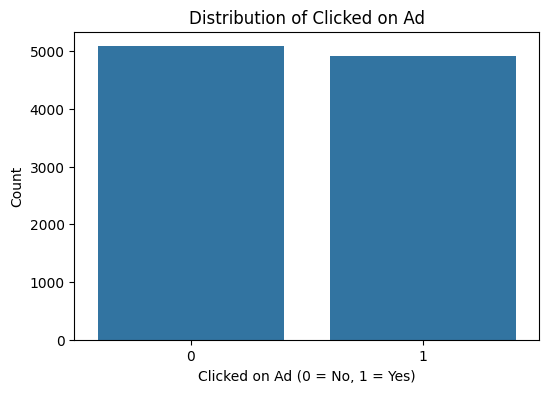

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Clicked on Ad')
plt.title('Distribution of Clicked on Ad')
plt.xlabel('Clicked on Ad (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

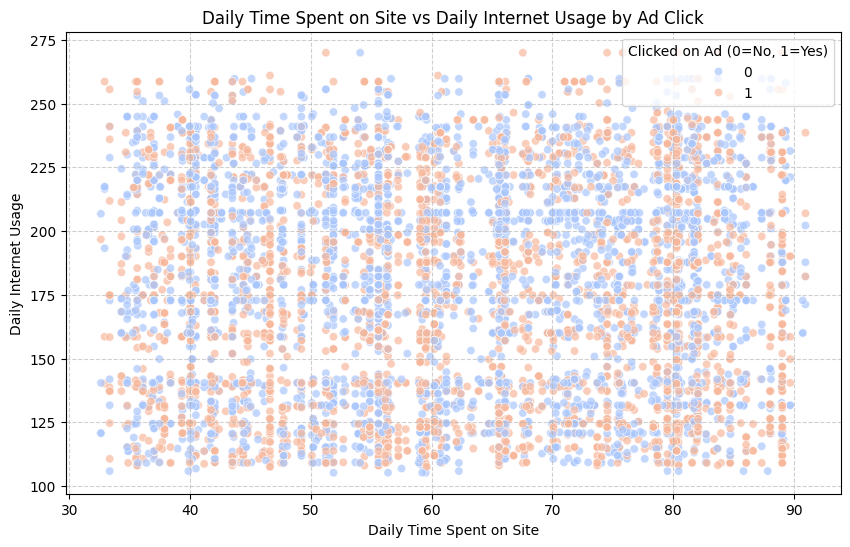

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Daily Time Spent on Site', y='Daily Internet Usage', hue='Clicked on Ad', palette='coolwarm', alpha=0.7)
plt.title('Daily Time Spent on Site vs Daily Internet Usage by Ad Click')
plt.xlabel('Daily Time Spent on Site')
plt.ylabel('Daily Internet Usage')
plt.legend(title='Clicked on Ad (0=No, 1=Yes)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [8]:
StringfeatureCol = ['Ad Topic Line', 'City', 'Country']

In [9]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

for col in StringfeatureCol:
    df[col + '_encoded'] = label_encoder.fit_transform(df[col])

print("DataFrame after Label Encoding:")
display(df[['Ad Topic Line', 'Ad Topic Line_encoded', 'City', 'City_encoded', 'Country', 'Country_encoded']].head())

DataFrame after Label Encoding:


,Ad Topic Line,Ad Topic Line_encoded,City,City_encoded,Country,Country_encoded
0,Decentralized real-time circuit,96,Lisafort,234,Svalbard & Jan Mayen Islands,174
1,Optional full-range projection,301,West Angelabury,460,Singapore,166
2,Total 5thgeneration standardization,484,Reyesfurt,379,Guadeloupe,71
3,Balanced empowering success,24,New Michael,269,Zambia,205
4,Total 5thgeneration standardization,484,West Richard,495,Qatar,149


Splitting the data into training and testing data set

Training the Random Forest model.

 Model Accuracy 
Accuracy: 84.00%

Detailed Report 
              precision    recall  f1-score   support

           0       0.83      0.86      0.84      1014
           1       0.85      0.82      0.84       986

    accuracy                           0.84      2000
   macro avg       0.84      0.84      0.84      2000
weighted avg       0.84      0.84      0.84      2000



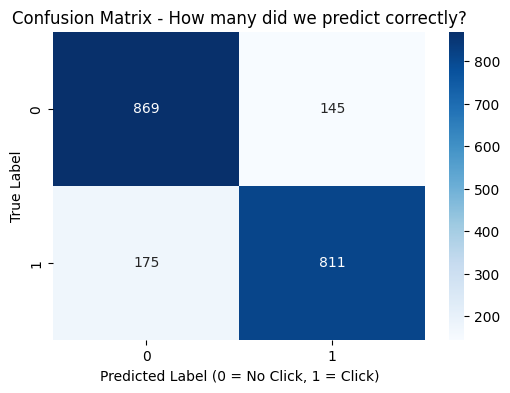

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# Apply Label Encoding to 'Gender' column
label_encoder = LabelEncoder()
df['Gender_encoded'] = label_encoder.fit_transform(df['Gender'])

X = df.drop(['Clicked on Ad', 'Ad Topic Line', 'City', 'Country', 'Gender', 'Timestamp'], axis=1)
y = df['Clicked on Ad']

# Training (80%) and Testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training the Random Forest model.")
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

predictions = model.predict(X_test)

print("\n Model Accuracy ")
print(f"Accuracy: {accuracy_score(y_test, predictions) * 100:.2f}%\n")

print("Detailed Report ")
print(classification_report(y_test, predictions))

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, predictions), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - How many did we predict correctly?')
plt.xlabel('Predicted Label (0 = No Click, 1 = Click)')
plt.ylabel('True Label')
plt.show()